In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [83]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Spectral", n_colors=12)

# 1. Handling the data

In [84]:
df = pd.read_csv('data/forPython_try2.csv', sep = ';', decimal = ',')
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,Before thawing,US,0.0000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,0.9940,0.00,0.0000,0.000,0.00600
1,Before thawing - Pre-sort,cDC1 no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
2,Before thawing - Pre-sort,cDC1 change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
3,Before thawing - Pre-sort,cDC1 change 1 of 2,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
4,Before thawing - Pre-sort,HSC no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904


In [85]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Before thawing - Pre-sort,cDC1 no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
2,Before thawing - Pre-sort,cDC1 change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
3,Before thawing - Pre-sort,cDC1 change 1 of 2,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
4,Before thawing - Pre-sort,HSC no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
5,Before thawing - Pre-sort,HSC change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904


In [86]:
df[df["Time"] == "Day 1"]

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
21,Day 1,cDC1 no change,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
22,Day 1,cDC1 change everyday,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
23,Day 1,cDC1 change 1 of 2,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
24,Day 1,HSC no change,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
25,Day 1,HSC change everyday,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
26,Day 1,HSC change 1 of 2,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [87]:
# Not needed, just helped to visualize data
df_day1 = df[df["Time"] == "Day 1"]
df_day1_cDC1_nochange = df_day1[df_day1["Sample"] == "cDC1 no change"]
df_day1_cDC1_change_everyday = df_day1[df_day1["Sample"] == "cDC1 change eveyday"]
df_day1_HSC_nochange = df_day1[df_day1["Sample"] == "HSC no change"]
df_day1_HSC_change1of2 = df_day1[df_day1["Sample"] == "HSC change 1 of 2"]


In [88]:
df_day1

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
21,Day 1,cDC1 no change,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
22,Day 1,cDC1 change everyday,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
23,Day 1,cDC1 change 1 of 2,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
24,Day 1,HSC no change,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
25,Day 1,HSC change everyday,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
26,Day 1,HSC change 1 of 2,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


# 2. Preprocessing

In [89]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [90]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [91]:
results_by_day = split_by_day(df)

## Cell type proportions

In [92]:
results_by_day

{'Before thawing - Pre-sort':                         Time                Sample    cDC1  Macrophages  \
 1  Before thawing - Pre-sort        cDC1 no change  0.0099       0.0546   
 2  Before thawing - Pre-sort  cDC1 change everyday  0.0099       0.0546   
 3  Before thawing - Pre-sort    cDC1 change 1 of 2  0.0099       0.0546   
 4  Before thawing - Pre-sort         HSC no change  0.0099       0.0546   
 5  Before thawing - Pre-sort   HSC change everyday  0.0099       0.0546   
 6  Before thawing - Pre-sort    HSC change 1 of 2   0.0099       0.0546   
 
       cDC2    pDCs      MDP  Monocytes      HSC  T cells  DCPs  B cells  \
 1  0.02208  0.0195  0.00022     0.0841  0.00066   0.0906  0.21   0.0723   
 2  0.02208  0.0195  0.00022     0.0841  0.00066   0.0906  0.21   0.0723   
 3  0.02208  0.0195  0.00022     0.0841  0.00066   0.0906  0.21   0.0723   
 4  0.02208  0.0195  0.00022     0.0841  0.00066   0.0906  0.21   0.0723   
 5  0.02208  0.0195  0.00022     0.0841  0.00066   0.0906

In [93]:
before_thawing_pre_sort_df = results_by_day["Before thawing - Pre-sort"].copy()
after_thawing_post_sort_df = results_by_day["Before thawing - Sorted"].copy()
day0_df = results_by_day["Day 0"].copy()

# Keep only the first lines of each dataframe
before_thawing_pre_sort_df = before_thawing_pre_sort_df.iloc[:1]
after_thawing_post_sort_df = after_thawing_post_sort_df.iloc[:1]
day0_df = day0_df.iloc[:1]

# Change the name of the Time in that column so they are in the same plot
before_thawing_pre_sort_df["Time"] = "Before and after thawing"
after_thawing_post_sort_df["Time"] = "Before and after thawing"
day0_df["Time"] = "Before and after thawing"

# Change the name of the Sample in that column 
before_thawing_pre_sort_df["Sample"] = "Pre-sort"
after_thawing_post_sort_df["Sample"] = "Post-sort"
day0_df["Sample"] = "After thawing"

first_days_df = pd.concat([before_thawing_pre_sort_df, after_thawing_post_sort_df, day0_df])
first_days_df

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Before and after thawing,Pre-sort,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
7,Before and after thawing,Post-sort,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240
13,Before and after thawing,After thawing,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.615,0.00120,0.0100,0.19740


In [94]:
# Add first_days_df to results_by_day
results_by_day["First days"] = first_days_df
results_by_day["First days duplicate test"] = first_days_df

# Delete "Before thawing - Pre-sort", "Before thawing - Sorted", "Day 0" from results_by_day
del results_by_day["Before thawing - Pre-sort"]
del results_by_day["Before thawing - Sorted"]
del results_by_day["Day 0"]

# Move First days to the beginning of the dictionary
results_by_day = {"First days": results_by_day["First days"], **{k: v for k, v in results_by_day.items() if k != "First days"}}

In [95]:
results_by_day

{'First days':                         Time         Sample    cDC1  Macrophages     cDC2  \
 1   Before and after thawing       Pre-sort  0.0099       0.0546  0.02208   
 7   Before and after thawing      Post-sort  0.0024       0.0000  0.00000   
 13  Before and after thawing  After thawing  0.0020       0.0340  0.01640   
 
       pDCs      MDP  Monocytes      HSC  T cells   DCPs  B cells  \
 1   0.0195  0.00022    0.08410  0.00066   0.0906  0.210  0.07230   
 7   0.0001  0.00000    0.00025  0.00470   0.6650  0.303  0.00055   
 13  0.0008  0.00280    0.06920  0.00000   0.0512  0.615  0.00120   
 
     NK cells, Eosinophils, granulocytes, neutrophils  Others   
 1                                             0.1570  0.27904  
 7                                             0.0016  0.02240  
 13                                            0.0100  0.19740  ,
 'Day 1':      Time                Sample    cDC1  Macrophages     cDC2     pDCs  MDP  \
 21  Day 1        cDC1 no change  0.0057    

## DCP proportions

In [96]:
sns.color_palette("Spectral", n_colors=12)

[(0.7803152633602461, 0.182160707420223, 0.2968089196462899),
 (0.8996539792387543, 0.340715109573241, 0.2848904267589389),
 (0.9679354094579008, 0.5074202229911572, 0.2996539792387543),
 (0.9923875432525952, 0.6938869665513263, 0.3900807381776239),
 (0.9954632833525567, 0.8476739715494039, 0.519261822376009),
 (0.9985390234525182, 0.9547097270280661, 0.6730488273740869),
 (0.9634755863129566, 0.9853902345251826, 0.6920415224913495),
 (0.8656670511341794, 0.9460207612456749, 0.6034602076124567),
 (0.6841983852364477, 0.8722029988465976, 0.6403690888119954),
 (0.48489042675893923, 0.7940023068050751, 0.6458285274894272),
 (0.30403690888119955, 0.6537485582468281, 0.6913494809688582),
 (0.24006151480199922, 0.47635524798154555, 0.7141868512110727)]

In [97]:
# Keep only the DCP proportions
dcp_proportions = df.pivot(index='Time', columns='Sample', values='DCPs')
dcp_proportions

Sample,HSC change 1 of 2,HSC change everyday,HSC no change,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,
Before thawing - Pre-sort,0.2100,0.2100,0.2100,0.2100,0.2100,0.2100
Before thawing - Sorted,0.3030,0.3030,0.3030,0.3030,0.3030,0.3030
Day 0,0.6150,0.6150,0.6150,0.6150,0.6150,0.6150
Day 1,0.0957,0.0711,0.0711,0.0709,0.0838,0.0709
Day 2,0.3270,0.2440,0.2710,0.2450,0.1860,0.2120
Day 3,0.3540,0.2810,0.3270,0.3540,0.4010,0.3200
Day 4,0.1680,0.1800,0.1450,0.1810,0.1810,0.1530
Day 5,0.0432,0.0431,0.0676,0.0392,0.0738,0.0482
Day 6,0.0145,0.0249,0.0179,0.0134,0.0247,0.0146


# 3. Figures

## Proportion of cell types

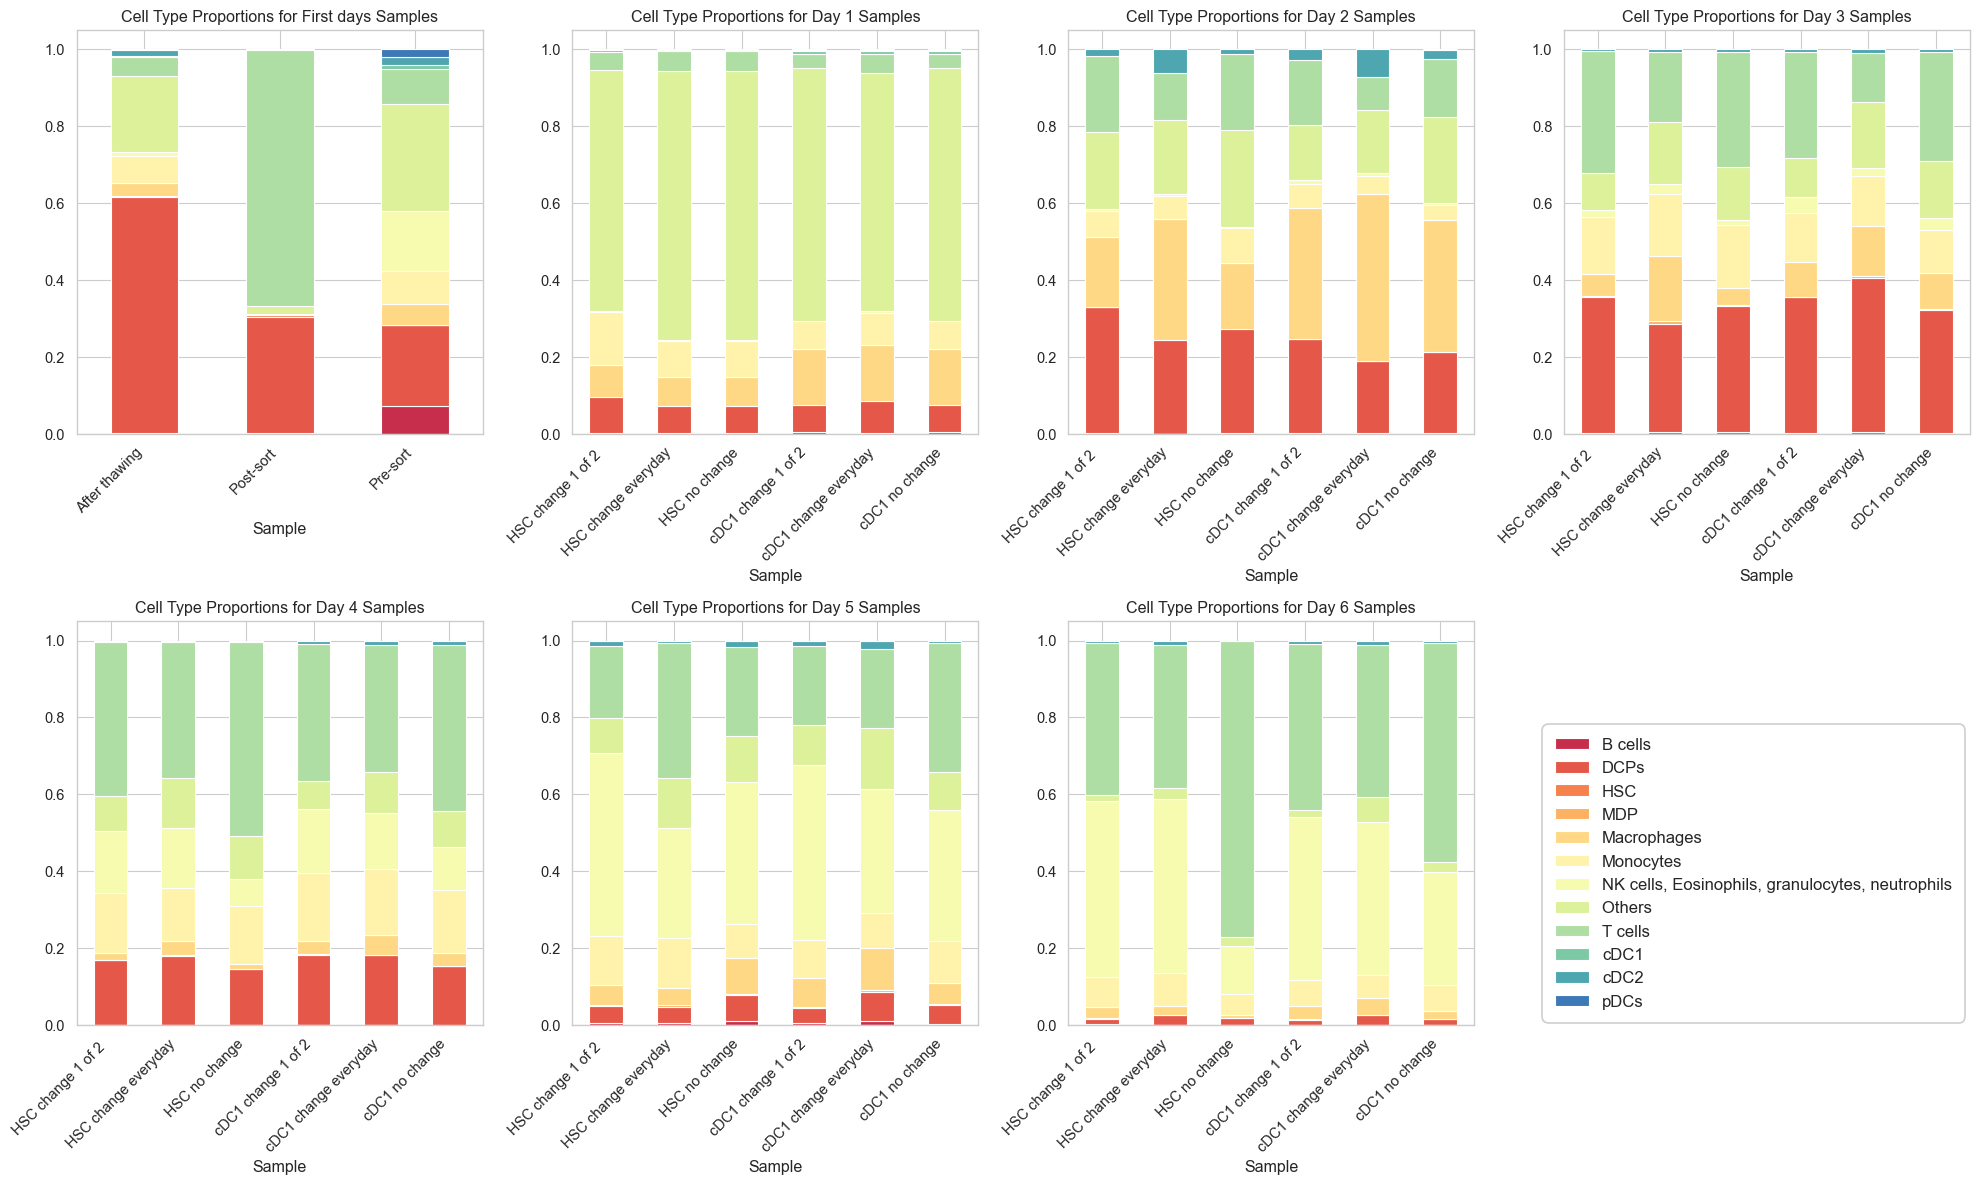

In [98]:
# Plot a figure with 7 subplots arranged in 4 rows / 2 columns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))
days = list(results_by_day.keys())

sns.set_palette("Spectral", 12)

max_plots = 7
last_ax = None

for i, ax in enumerate(axes.flatten()):
    if i == max_plots:
        ax.set_visible(False)
        continue
    
    if i < len(days):
        day = days[i]
        day_data = results_by_day[day]
        day_proportions = pd.DataFrame()
        
        for sample_name, sample_data in split_by_sample(day_data).items():
            sample_proportions = sample_data.iloc[:, 2:].copy()
            sample_proportions.insert(0, "Sample", sample_name)
            day_proportions = pd.concat([day_proportions, sample_proportions], ignore_index=True)
        
        day_proportions_plot = day_proportions.melt(id_vars='Sample', var_name='Cell Type', value_name='Proportion')
        day_proportions_plot_pivot = day_proportions_plot.pivot(index='Sample', columns='Cell Type', values='Proportion')
        day_proportions_plot_pivot.plot(kind='bar', stacked=True, ax=ax)
        
        ax.set_title(f'Cell Type Proportions for {day} Samples')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

        ax.legend_.remove()    # ← REMOVE per-subplot legends
        last_ax = ax

plt.tight_layout()

# ---- Figure-level legend at bottom ----
handles, labels = last_ax.get_legend_handles_labels()

# Create a global legend at the bottom with styling
legend = fig.legend(
    handles,
    labels,
    loc='lower right',
    bbox_to_anchor=(0.99, 0.14),
    ncol=1,
    frameon=True,
    fontsize=12,
)

# Style the legend frame
frame = legend.get_frame()
#frame.set_edgecolor("black")       # Border color
frame.set_linewidth(1.2)           # Border thickness
frame.set_facecolor("white")       # Background color
frame.set_alpha(0.95)              # Slight transparency
frame.set_boxstyle("round,pad=0.4")  # Rounded corners + internal padding

plt.savefig('Figures/assessing_viability/DCP_proportions_across_days.png', dpi=300, bbox_inches='tight')
plt.show()


## DCP proportions

In [99]:
sns.set_palette("Spectral", n_colors=6)

<Figure size 1000x600 with 0 Axes>

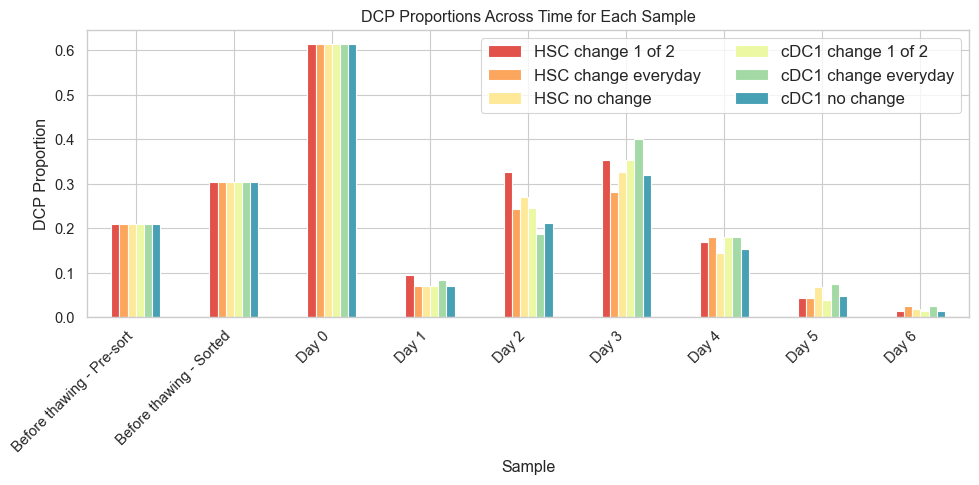

In [100]:
# Plot bar chart of DCP proportions across time for each sample
plt.figure(figsize=(10, 6))
dcp_proportions.plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title="", frameon=True, ncol=2, fontsize = 12)
plt.savefig('Figures/assessing_viability/DCP_proportions_bar_chart.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()  

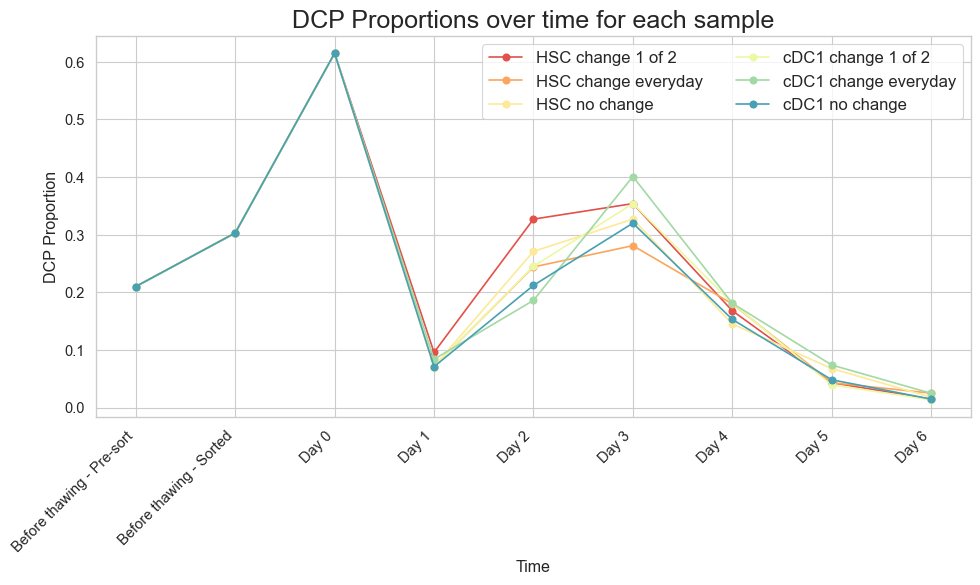

In [101]:
# Plotting DCP proportions with line plot
plt.figure(figsize=(10, 6))
for sample in dcp_proportions.columns:
    plt.plot(dcp_proportions.index, dcp_proportions[sample], marker='o', label=sample)  

plt.title('DCP Proportions over time for each sample', fontsize=18)
plt.xlabel('Time')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title="", frameon=True, ncol=2, fontsize=12)
plt.tight_layout()
plt.savefig('Figures/assessing_viability/DCP_proportions_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Viability 

In [102]:
df_from_viability = pd.read_csv('data/viability.csv', sep = ';', decimal = ',')
cell_concentration = df_from_viability.iloc[:, :5].copy()
#viability = df_from_viability[17:26].copy()


In [103]:
# Take 4 first columns as cell concentration data
cell_concentration = df_from_viability.iloc[:, :4].copy()
cell_concentration

,Day,State,Condition,Concentration (cells/mL)
0,Day 0,NaN,cDC1 change everyday,250000
1,Day 1,Live,cDC1 change everyday,130000
2,Day 1,Dead,cDC1 change everyday,5000
3,Day 2,Live,cDC1 change everyday,70000
4,Day 2,Dead,cDC1 change everyday,20000
...,...,...,...,...
73,Day 4,Dead,HSC - no change,10000
74,Day 5,Live,HSC - no change,290000
75,Day 5,Dead,HSC - no change,10000
76,Day 6,Live,HSC - no change,260000


In [104]:
live_cells = cell_concentration[cell_concentration["State"] == "Live"].copy()
live_cells = live_cells.drop(columns=["State"])

dead_cells = cell_concentration[cell_concentration["State"] == "Dead"].copy()
dead_cells = dead_cells.drop(columns=["State"])

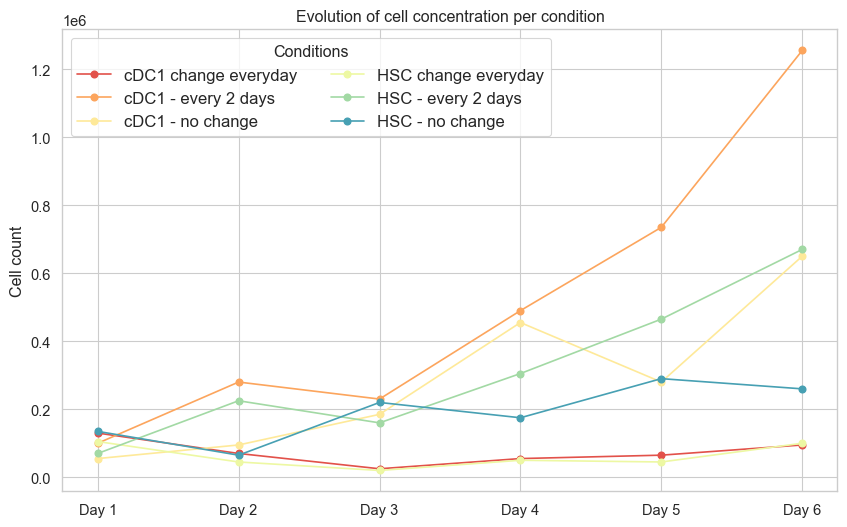

<Figure size 640x480 with 0 Axes>

In [105]:
# Plot the concentration of cells in each sample each day
plt.figure(figsize=(10, 6))

for condition in live_cells["Condition"].unique():
    condition_data = live_cells[live_cells["Condition"] == condition]
    plt.plot(condition_data["Day"], condition_data["Concentration (cells/mL)"], marker='o', label=condition)
    
plt.legend(title="Conditions", frameon=True, ncol=2, fontsize=12)
plt.title("Evolution of cell concentration per condition")
plt.ylabel("Cell count")
plt.show()

plt.savefig("Figures/assessing_viability/cellconcentration")

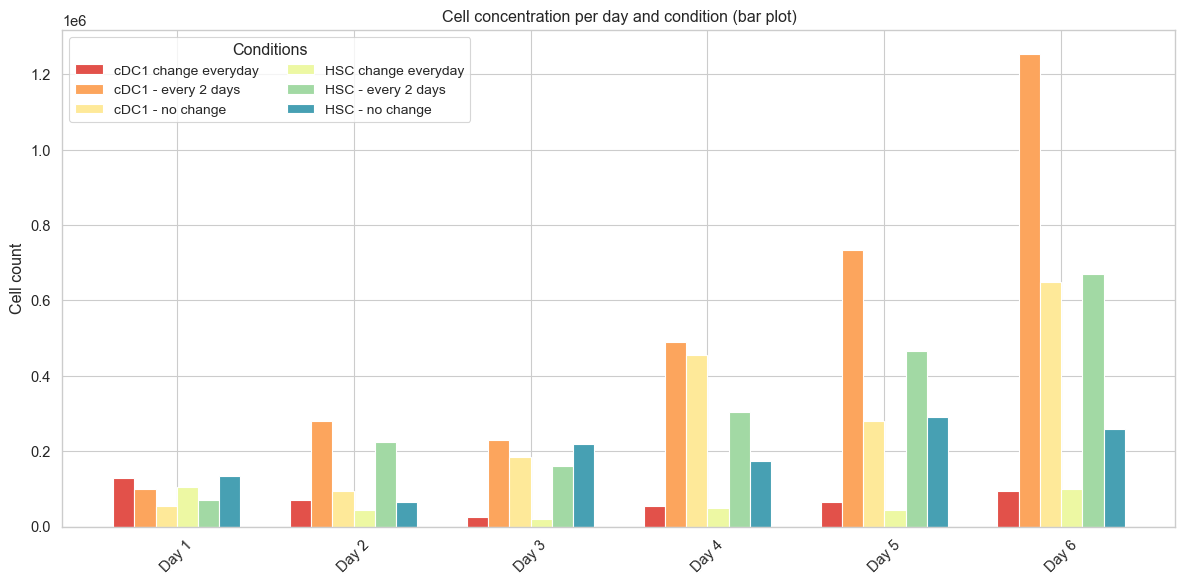

In [106]:
# Bar plot of comparison of concentration of cells in each sample each day
# Keep only Live cells if needed
df = live_cells.copy()

# Make sure Days are sorted correctly
df["Day"] = pd.Categorical(df["Day"], ordered=True, categories=sorted(df["Day"].unique()))

# All condition names (your samples)
conditions = df["Condition"].unique()
days = df["Day"].unique()

x = np.arange(len(days))  # positions for the days
width = 0.12              # bar width (adjust depending on number of conditions)

plt.figure(figsize=(12,6))

# Loop through conditions and create offset bars
for i, condition in enumerate(conditions):
    cond_data = df[df["Condition"] == condition].sort_values("Day")
    plt.bar(
        x + i*width,
        cond_data["Concentration (cells/mL)"],
        width,
        label=condition
    )

# Formatting
plt.xticks(x + width*(len(conditions)-1)/2, days, rotation=45)
plt.ylabel("Cell count")
plt.title("Cell concentration per day and condition (bar plot)")
plt.legend(title="Conditions", frameon=True, fontsize=10, ncol=2)

plt.tight_layout()
plt.show()


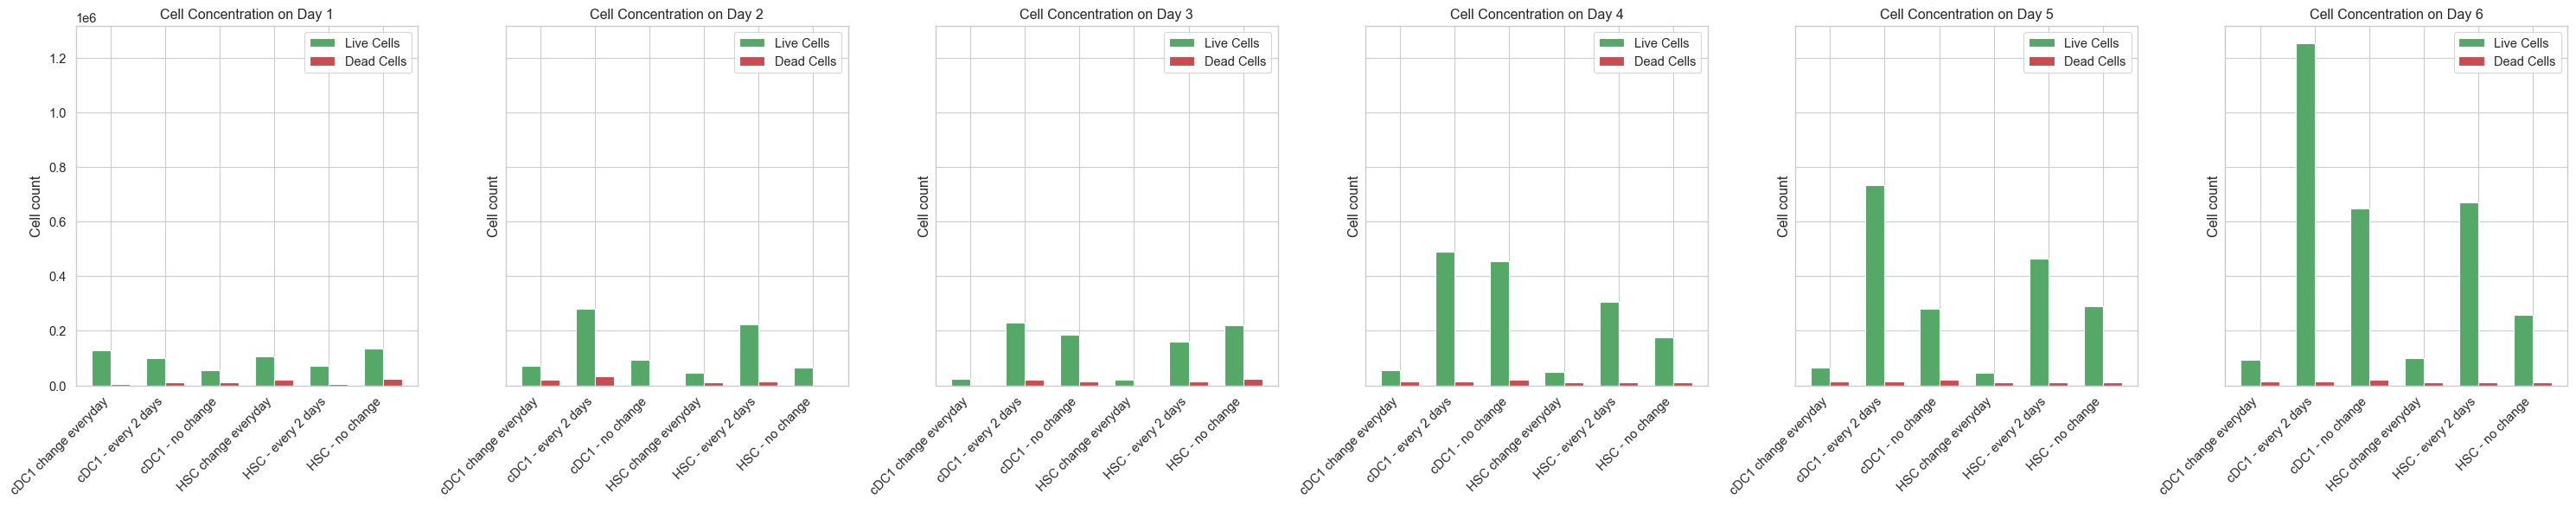

In [107]:
# Bar plot of each condition per day with live and dead cells side by side
# Each ax will be a day, with bars for live and dead cells per condition
days = live_cells["Day"].unique()
num_days = len(days)
fig, axes = plt.subplots(nrows=1, ncols=num_days, figsize=(5*num_days, 6), sharey=True)
for i, day in enumerate(days):
    ax = axes[i]
    
    live_day_data = live_cells[live_cells["Day"] == day]
    dead_day_data = dead_cells[dead_cells["Day"] == day]
    
    x = np.arange(len(live_day_data["Condition"]))  # positions for the conditions
    width = 0.35  # bar width

    ax.bar(x - width/2, live_day_data["Concentration (cells/mL)"], width, label='Live Cells', color='g')
    ax.bar(x + width/2, dead_day_data["Concentration (cells/mL)"], width, label='Dead Cells', color='r')

    ax.set_title(f'Cell Concentration on {day}')
    ax.set_xticks(x)
    ax.set_xticklabels(live_day_data["Condition"], rotation=45, ha='right')
    ax.set_ylabel('Cell count')
    ax.legend()
plt.tight_layout()
plt.show()